# EMG Comparative Analysis Demo
This notebook showcases how to load the healthy dataset, extract gesture segments, and generate the publication figures using `emg_comparative_analysis.py`.

In [19]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if (project_root / 'md-emg-python').exists():
    repo_root = project_root
else:
    repo_root = project_root.parent

module_path = repo_root
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))

data_dir = module_path / 'data' / 'healthy'
results_dir = module_path / 'results-analysis'
results_dir.mkdir(exist_ok=True)
print(f"Using data directory: {data_dir}")
print(f"Figures will be saved to: {results_dir}")

Using data directory: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/data/healthy
Figures will be saved to: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/results-analysis


In [20]:
import matplotlib.pyplot as plt
from emg_comparative_analysis import (
    load_real_data,
    generate_example_data,
    EMGDataLoader,
    EMGAnalyzer,
    DEFAULT_FS_HZ
)

In [21]:
data_dict, inferred_fs = load_real_data(data_dir)
if data_dict is None:
    data_dict = generate_example_data(fs_hz=DEFAULT_FS_HZ)
    inferred_fs = DEFAULT_FS_HZ
    print('Real data not found. Using synthetic example data instead.')
else:
    print(f'Inferred sampling rate: {inferred_fs:.2f} Hz')

object_ids = sorted({obj_id for condition_data in data_dict.values() for obj_id in condition_data.keys()})
if not object_ids:
    object_ids = list(range(6))
elif len(object_ids) > 6:
    print(f'Detected {len(object_ids)} gesture IDs; limiting analysis to first 6: {object_ids[:6]}')
    object_ids = object_ids[:6]

print(f'Analyzing objects: {object_ids}')

Scanning: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/data/healthy/S0/emg_logs
Scanning: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/data/healthy/S1/emg_logs
Scanning: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/data/healthy/S10/emg_logs
  Skipping session_01_timestamps.json: unknown condition 'None'
  Skipping session_02_timestamps.json: unknown condition 'None'
  Skipping session_03_timestamps.json: unknown condition 'None'
  Skipping session_04_timestamps.json: unknown condition 'None'
  Skipping session_05_timestamps.json: unknown condition 'None'
  Skipping session_07_timestamps.json: unknown condition 'None'
  Skipping session_08_timestamps.json: unknown condition 'None'
  Skipping session_09_timestamps.json: unknown condition 'None'
  Skipping session_10_timestamps.json: unknown condition 'None'
Scanning: /Users/ffmacair/Documents/GitWorks/PhD/EMG_Exo/md-emg-python/data/healthy/S2/emg_logs
Scanning: /Users/ffmacair/Documents/Git

In [22]:
loader = EMGDataLoader(data_dir)
analyzer = EMGAnalyzer(loader, fs_hz=inferred_fs or DEFAULT_FS_HZ)
target_object = object_ids[0] if object_ids else 0
print(f'Primary object: {target_object}')

Primary object: 1


Saved: results-analysis/notebook_figureB_object_1.png


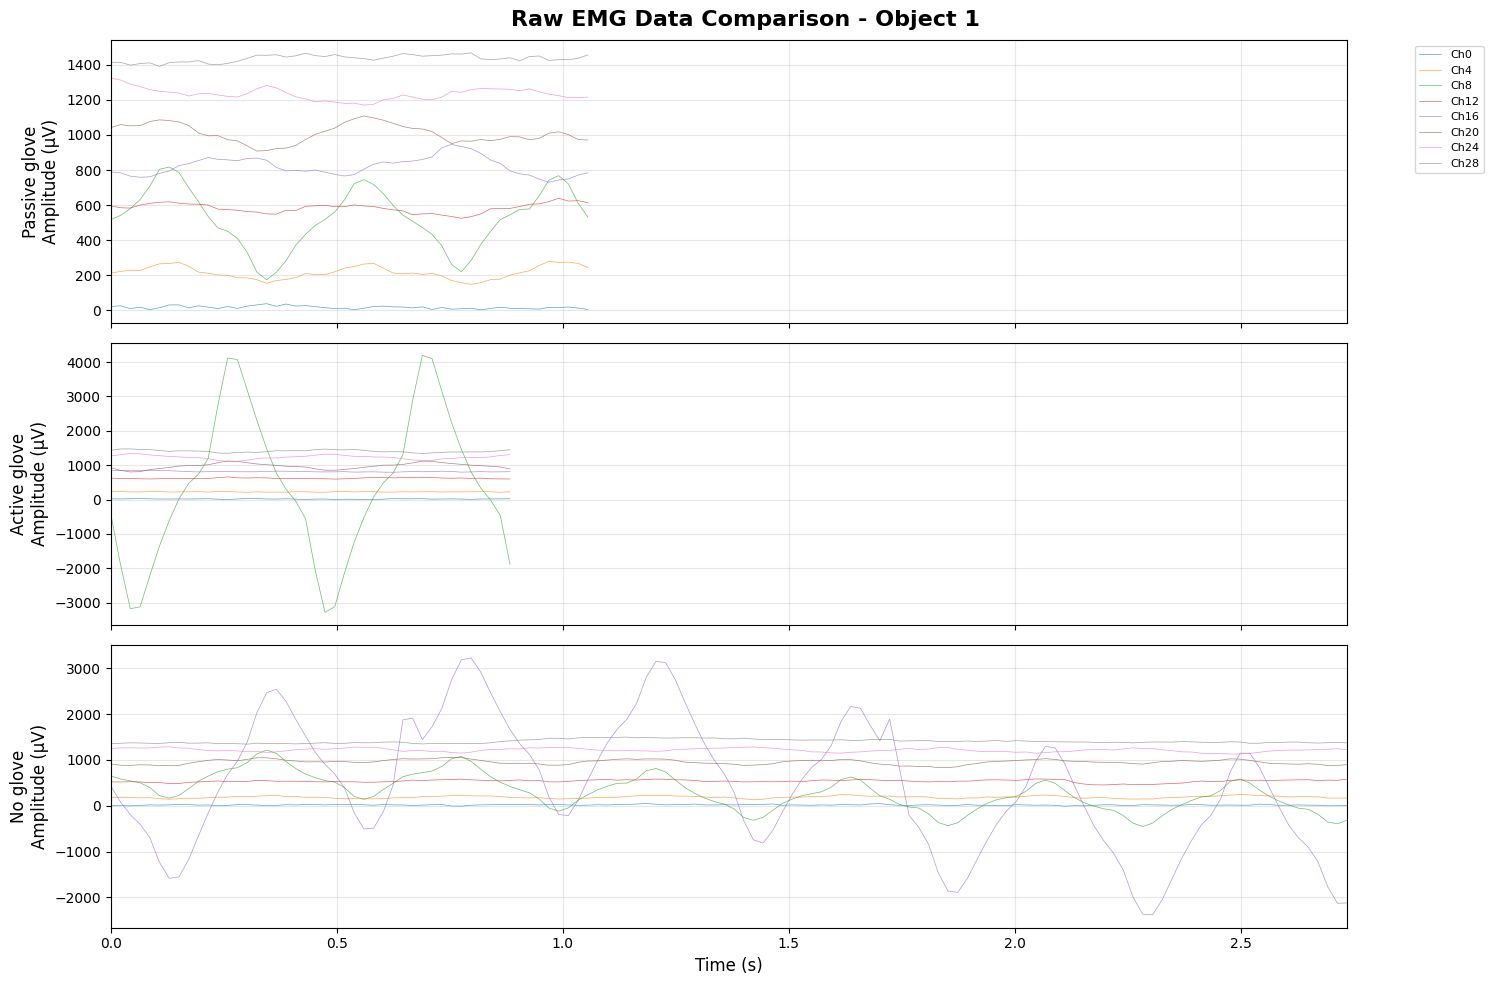

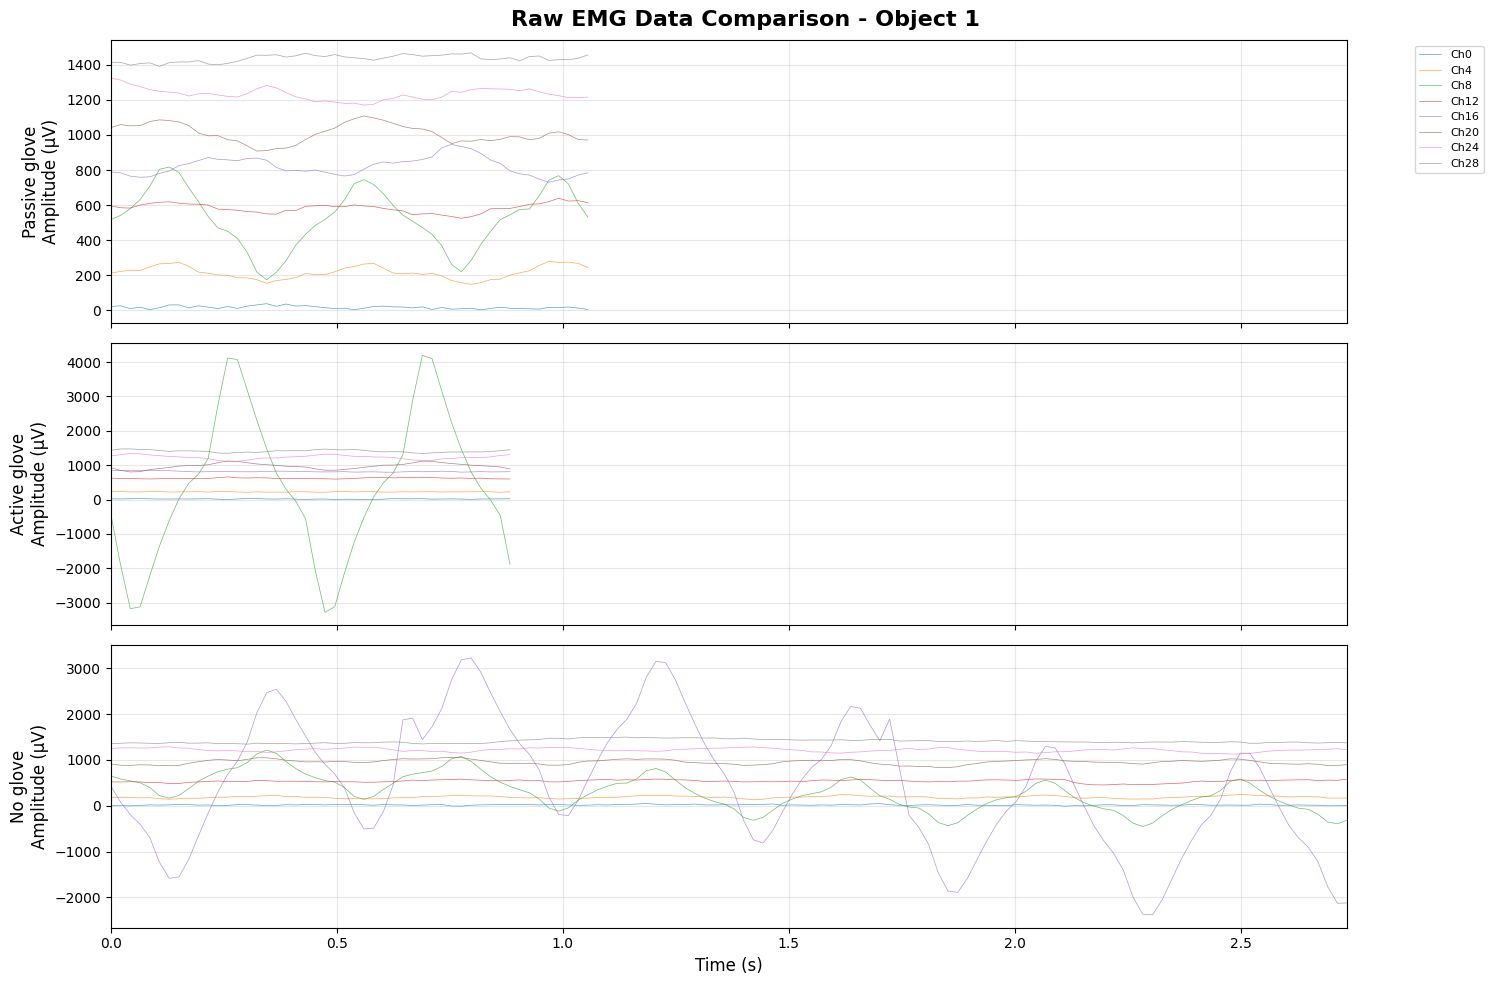

In [23]:
fig_b = analyzer.figure_b_raw_comparison(data_dict, object_id=target_object, save_prefix='notebook_figureB')
fig_b

Saved: results-analysis/notebook_figureC_heatmap_object_1.png


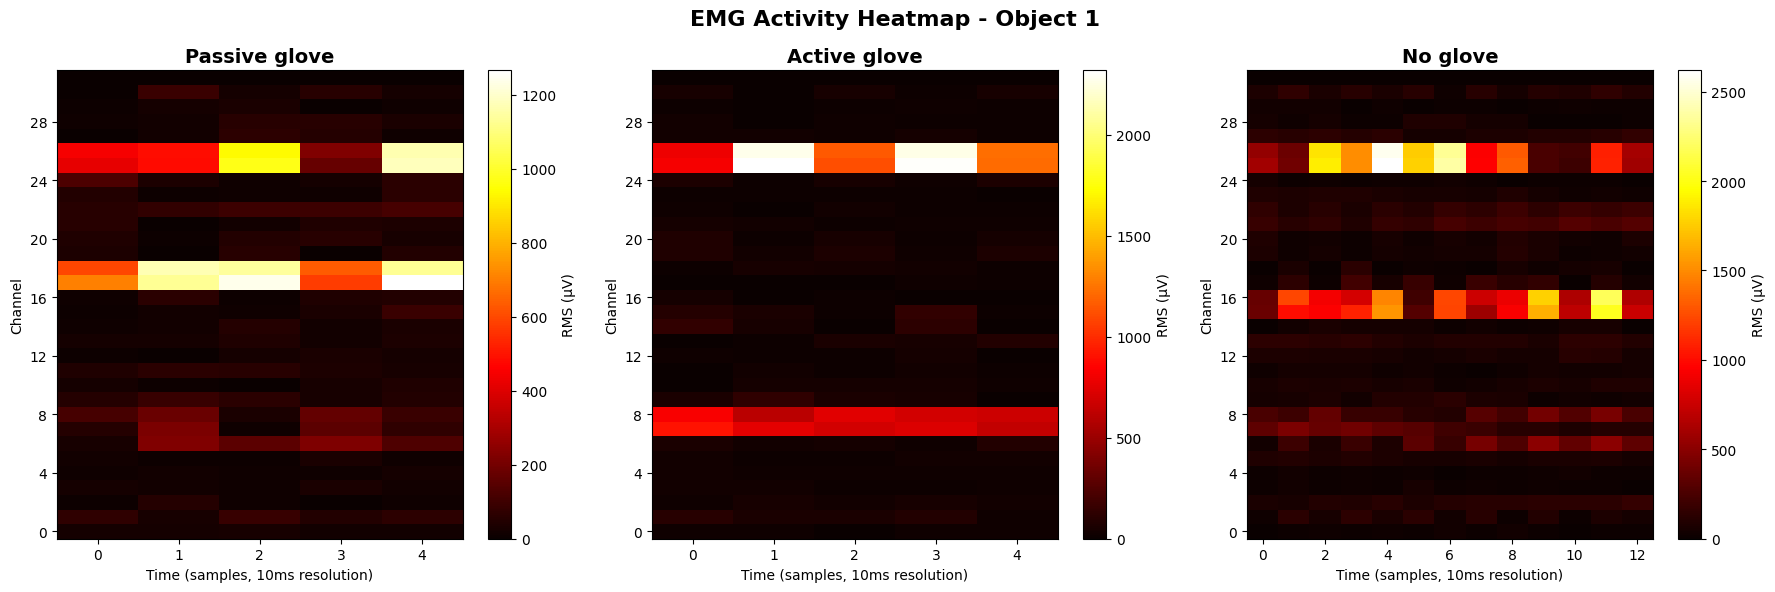

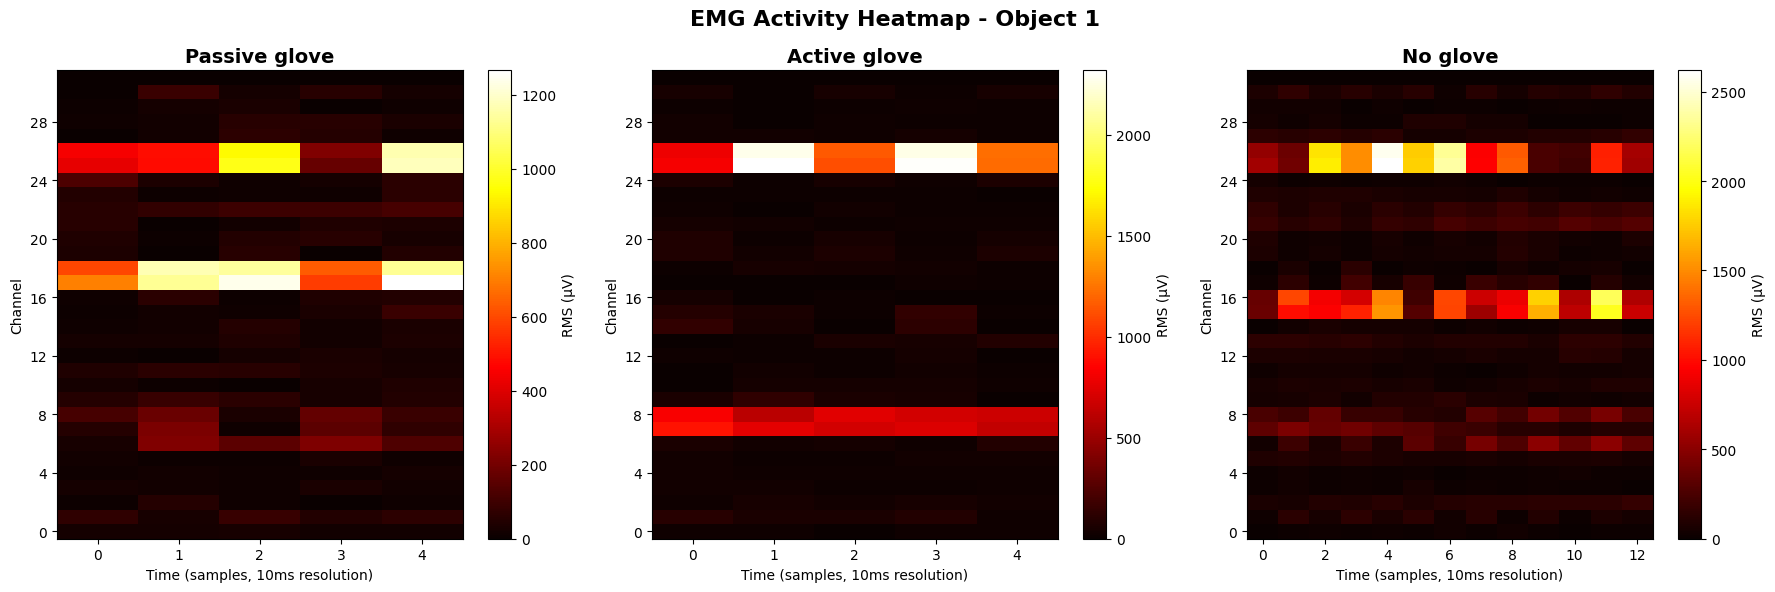

In [24]:
fig_heatmap = analyzer.figure_c_heatmap(data_dict, object_id=target_object, save_prefix='notebook_figureC_heatmap')
fig_heatmap

Saved: results-analysis/notebook_figureC_pca_objects_1_2_3_4_5_6.png


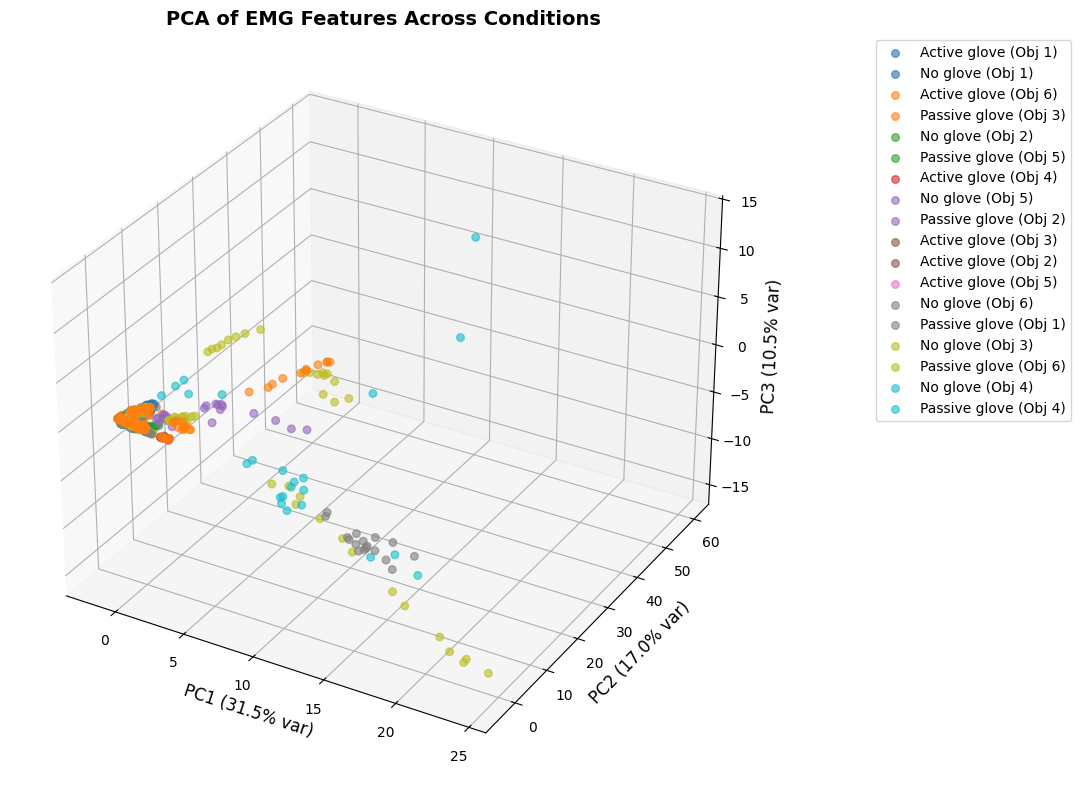

In [25]:
fig_pca = analyzer.figure_c_pca(data_dict, object_ids=object_ids, save_prefix='notebook_figureC_pca')
if fig_pca is not None:
    fig_pca
else:
    print('Not enough data to compute PCA.')

In [26]:
time_df = analyzer.analyze_time_consumption(data_dict, object_ids=object_ids)
time_df.head() if not time_df.empty else time_df


=== Time Consumption Analysis ===
        Condition  Object  count      mean       std       min        max
0    Active glove       1      5  1.378483  0.581148  0.796935   2.218496
1    Active glove       2     10  1.404329  0.435631  0.796935   2.132341
2    Active glove       3     15  1.510588  0.449439  0.883091   2.240035
3    Active glove       4      3  1.098479  0.432388  0.796935   1.593871
4    Active glove       5      4  1.674641  0.318684  1.206173   1.916953
5    Active glove       6     16  1.492908  0.494656  0.818474   2.218496
6        No glove       1      6  1.672846  0.652262  0.861552   2.756966
7        No glove       2     11  1.464638  0.402147  0.861552   2.240035
8        No glove       3     18  1.546007  0.458669  0.861552   2.670811
9        No glove       4      8  1.540024  0.362796  0.969246   2.175418
10       No glove       5      7  1.649256  0.616885  0.861552   2.670811
11       No glove       6     20  2.221727  2.754221  0.904629  13.763290
12 

,Condition,Object,Segment,Duration (s)
0,Passive glove,1,0,1.076940
1,Passive glove,1,1,1.313867
2,Passive glove,1,2,2.175418
3,Passive glove,1,3,1.529254
4,Passive glove,2,0,1.292328


Results are written to the shared `results-analysis/` directory. Each execution overwrites the notebook-specific files with the `notebook_` prefix so you can quickly compare outputs across objects or conditions.